# Predicción de nivel de obesidad.


## Dataset: Estimation of Obesity Levels UCI Machine Learning Repository

#### Dataset: Estimation of Obesity Levels (UCI Machine Learning Repository)

### 1. Justificación del Dataset

He seleccionado el dataset "Estamation Of Obesity Based on Eating Habits and Physical Condition" del repositorio UCI Machine Learning Repository.

**Motivos de la elección:**

- **Relevancia:** La obesidad es un problema de salud pública global. Un modelo predictivo puede ayudar a clínicas, aseguradoras o empresas de salud a identificar perfiles de riesgo y diseñar intervenciones preventivas.

- **Complejidad:** El dataset combina variables numéricas y categóricas, tiene 7 clases objetivo (clasificación multiclase), y requiere técnicas de codificación, normalización y manejo de clases.

- **Adecuación:** Con 2111 registros y 16 variables predictoras sobre hábitos alimentarios, condición física y factores demográficos, es ideal para construir un pipeline completo supervisado y complementarlo con análisis no supervisado (clustering).

### 2. Import y configuración ###

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='Set2')



### 3.Carga de datos y exploración inicial ###

In [29]:
# Carga del dataset
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

print('=== DIMENSIONES ===')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()
print('=== PRIMERAS FILAS ===')
df.head()

=== DIMENSIONES ===
Filas: 2111 | Columnas: 17

=== PRIMERAS FILAS ===


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [32]:
print('=== TIPOS DE VARIABLES ===')
print()
print(df.dtypes)
print()
print('=== VALORES NULOS ===')
print()
print(df.isnull().sum())
print(f'\nTotal nulos: {df.isnull().sum().sum()}')

=== TIPOS DE VARIABLES ===

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

=== VALORES NULOS ===

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC

In [33]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
print()
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===



,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


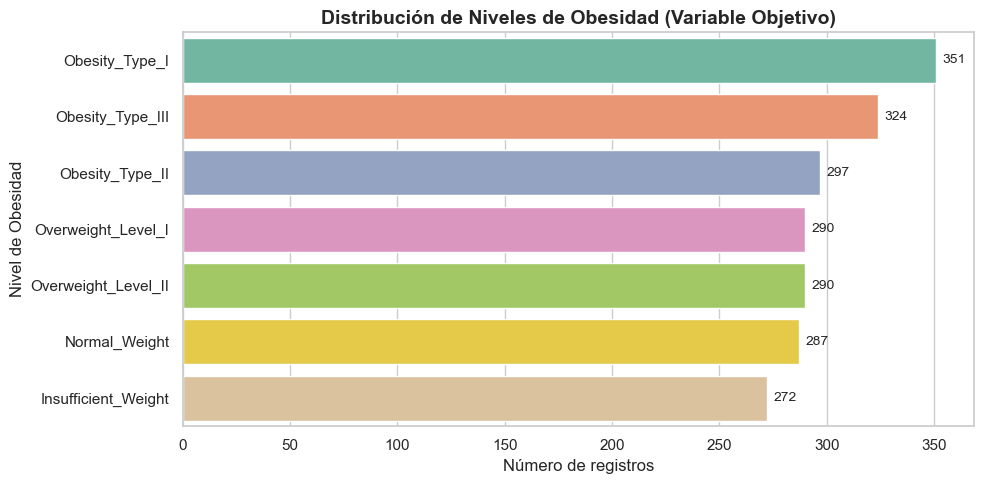


Distribución porcentual:

NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: proportion, dtype: float64


In [36]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(10, 5))
order = df['NObeyesdad'].value_counts().index
sns.countplot(data=df, y='NObeyesdad', order=order, palette='Set2', ax=ax)
ax.set_title('Distribución de Niveles de Obesidad (Variable Objetivo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
ax.set_ylabel('Nivel de Obesidad')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 3, p.get_y() + p.get_height()/2),
                va='center', fontsize=10)
plt.tight_layout()
plt.savefig('dist_objetivo.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nDistribución porcentual:')
print()
print((df['NObeyesdad'].value_counts(normalize=True)*100).round(2))

### 4. Análisis exploratorio de datos (EDA)

Variables numéricas (8): ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Variables categóricas (8): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


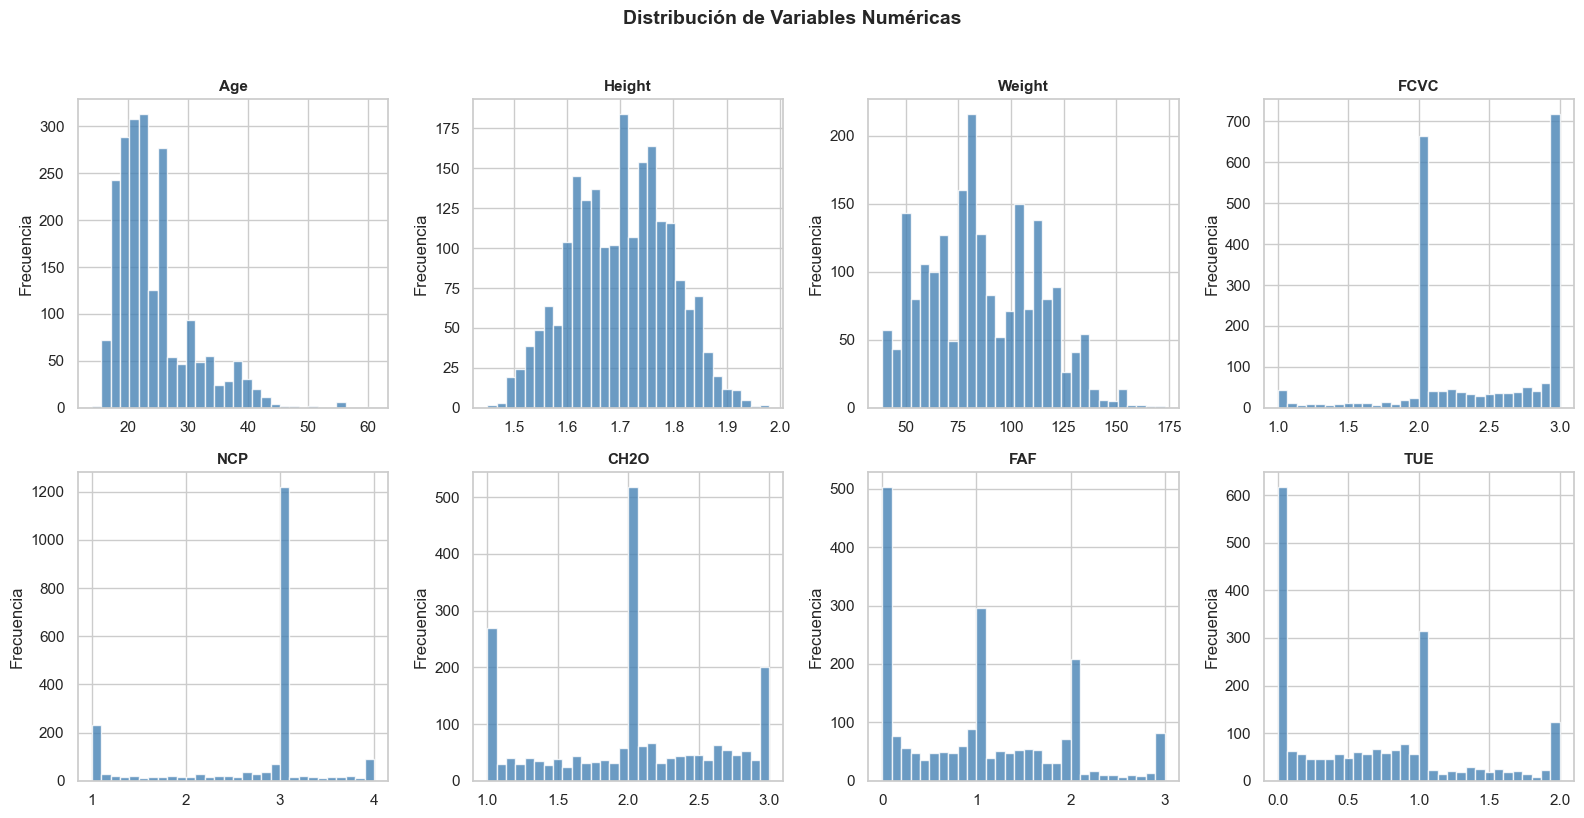

In [38]:
# Variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.drop('NObeyesdad').tolist()

print(f'Variables numéricas ({len(num_cols)}): {num_cols}')
print()
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hist_numericas.png', dpi=100, bbox_inches='tight')
plt.show()

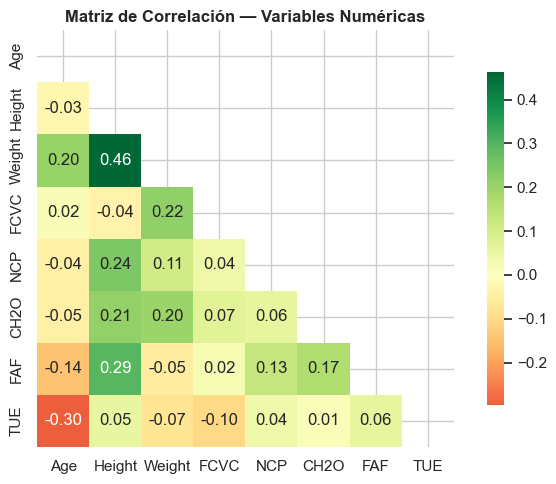

In [39]:
# Correlación entre variables numéricas
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=100, bbox_inches='tight')
plt.show()

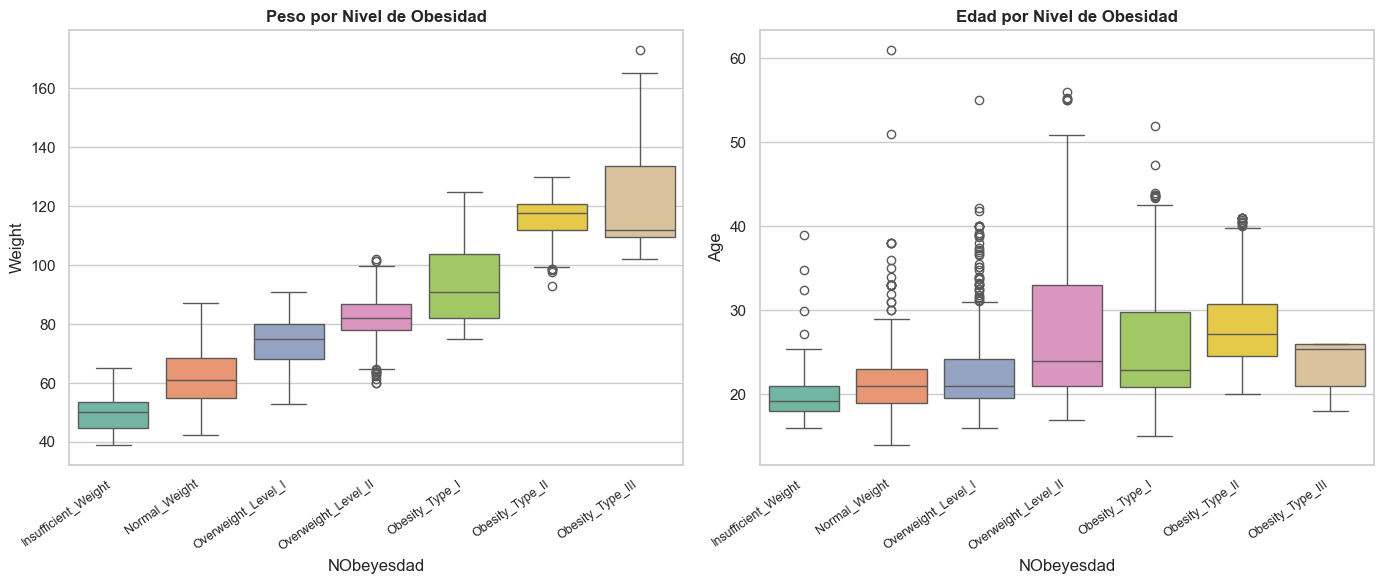

In [40]:
# Boxplots: Peso y Edad por nivel de obesidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order_box = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
             'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

sns.boxplot(data=df, x='NObeyesdad', y='Weight', order=order_box, palette='Set2', ax=axes[0])
axes[0].set_title('Peso por Nivel de Obesidad', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=9)

sns.boxplot(data=df, x='NObeyesdad', y='Age', order=order_box, palette='Set2', ax=axes[1])
axes[1].set_title('Edad por Nivel de Obesidad', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

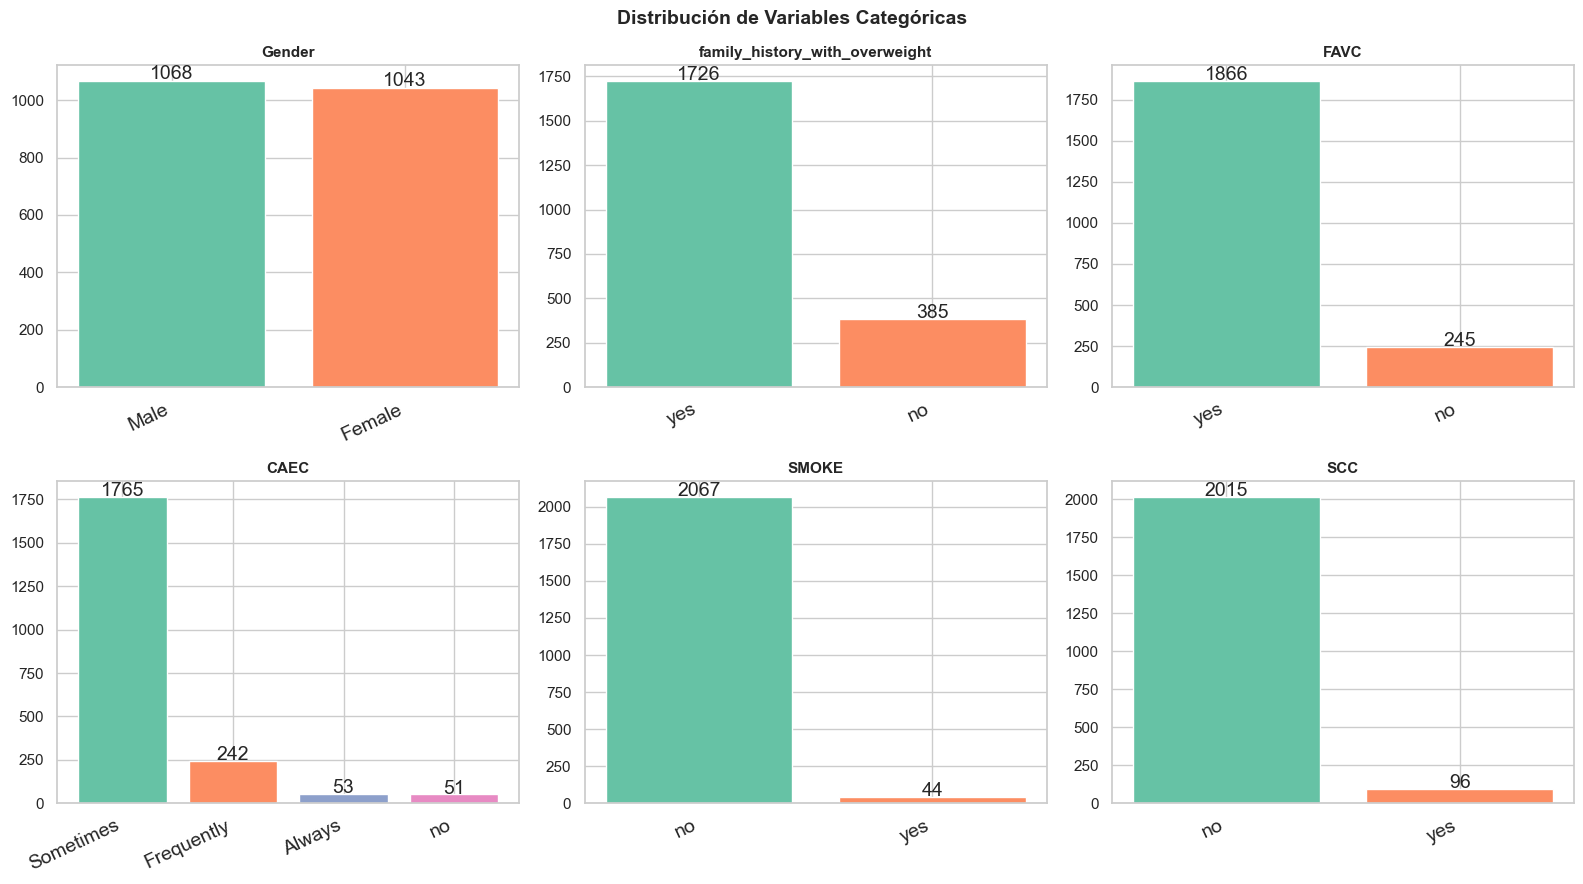

In [41]:
# Variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels() if hasattr(axes[i], 'get_xticklabels') else vc.index,
                             rotation=25, ha='right', fontsize=14)
    for j, (idx, val) in enumerate(vc.items()):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=14)
plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categoricas.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.Preprocesamiento y ingeniería de variables ###

In [44]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

df_proc = df.copy()

# --- Ingeniería de variables ---
# IMC (aunque la variable objetivo lo captura, es una feature útil y explicable)

df_proc['BMI'] = df_proc['Weight'] / (df_proc['Height'] ** 2)

# Codificación de variables binarias (yes/no) con LabelEncoder

binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
le = LabelEncoder()
for col in binary_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

# Codificación ordinal para variables con orden lógico
# CAEC y CALC: no -> Sometimes -> Frequently -> Always
caec_calc_order = [['no', 'Sometimes', 'Frequently', 'Always']]
oe = OrdinalEncoder(categories=caec_calc_order)
df_proc['CAEC'] = oe.fit_transform(df_proc[['CAEC']])
df_proc['CALC'] = oe.fit_transform(df_proc[['CALC']])

# MTRANS: One-Hot Encoding (sin orden natural)
df_proc = pd.get_dummies(df_proc, columns=['MTRANS'], drop_first=True)

# Codificación de la variable objetivo (ordinal natural)
obesity_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
                 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
obesity_map = {v: i for i, v in enumerate(obesity_order)}
df_proc['target'] = df_proc['NObeyesdad'].map(obesity_map)
df_proc = df_proc.drop(columns=['NObeyesdad'])

print('=== DATASET PREPROCESADO ===')
print()
print(f'Shape: {df_proc.shape}')
print()
print(f'Columnas: {df_proc.columns.tolist()}')
df_proc.head(10)

=== DATASET PREPROCESADO ===

Shape: (2111, 21)

Columnas: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking', 'target']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,BMI,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,target
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,...,0,0.0,1.0,0.0,24.386526,False,False,True,False,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,...,1,3.0,0.0,1.0,24.238227,False,False,True,False,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,...,0,2.0,1.0,2.0,23.765432,False,False,True,False,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,...,0,2.0,0.0,2.0,26.851852,False,False,False,True,2
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,...,0,0.0,0.0,1.0,28.342381,False,False,True,False,3
5,1,29.0,1.62,53.0,0,1,2.0,3.0,1.0,0,...,0,0.0,0.0,1.0,20.195092,False,False,False,False,1
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1.0,0,...,0,1.0,0.0,1.0,24.444444,False,True,False,False,1
7,1,22.0,1.64,53.0,0,0,2.0,3.0,1.0,0,...,0,3.0,0.0,1.0,19.705532,False,False,True,False,1
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1.0,0,...,0,1.0,1.0,2.0,20.199470,False,False,True,False,1
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1.0,0,...,0,1.0,1.0,0.0,22.985398,False,False,True,False,1


### 6. Divisón Train/Test y Escalado ###

In [46]:
X = df_proc.drop(columns=['target'])
y = df_proc['target']

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros')
print()
print(f'Distribución train: {y_train.value_counts().to_dict()}')
print()
print(f'Distribución test:  {y_test.value_counts().to_dict()}')

# Escalado estándar (media 0, std 1) — necesario para modelos sensibles a escala

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nEscalado aplicado correctamente.')

Train: 1688 registros | Test: 423 registros

Distribución train: {4: 281, 6: 259, 5: 237, 3: 232, 2: 232, 1: 229, 0: 218}

Distribución test:  {4: 70, 6: 65, 5: 60, 1: 58, 3: 58, 2: 58, 0: 54}

Escalado aplicado correctamente.


## 6. Selección de Variables — Importancia con Random Forest

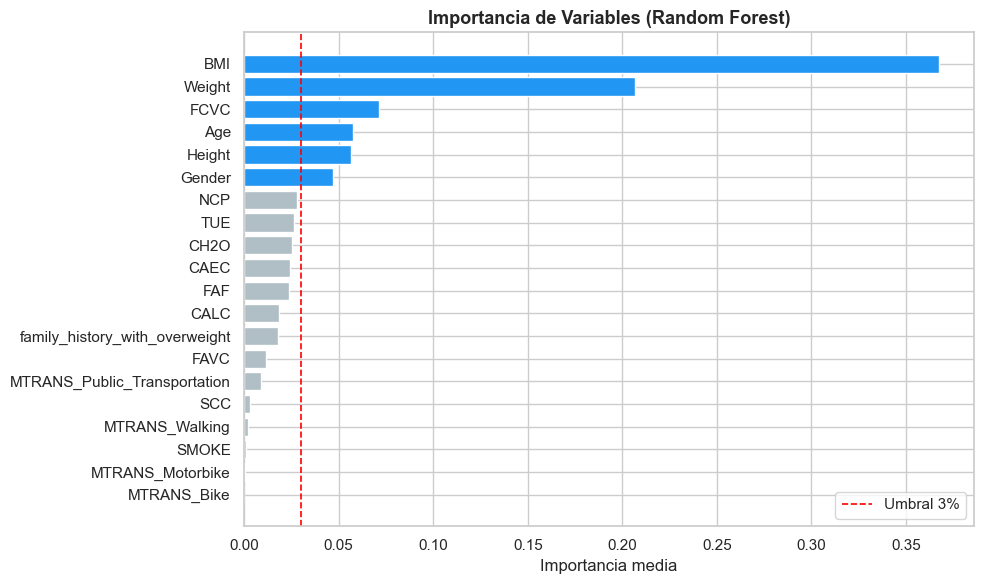

Variables seleccionadas (14): ['BMI', 'Weight', 'FCVC', 'Age', 'Height', 'Gender', 'NCP', 'TUE', 'CH2O', 'CAEC', 'FAF', 'CALC', 'family_history_with_overweight', 'FAVC']


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Ajustamos un RF rápido solo para obtener importancias
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importances = pd.Series(rf_imp.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if v > 0.03 else '#B0BEC5' for v in importances]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
ax.set_title('Importancia de Variables (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia media')
ax.axvline(0.03, color='red', linestyle='--', linewidth=1.2, label='Umbral 3%')
ax.legend()
plt.tight_layout()
plt.savefig('importancias.png', dpi=100, bbox_inches='tight')
plt.show()

# Selección: variables con importancia > 1%
top_features = importances[importances > 0.01].index.tolist()
print(f'Variables seleccionadas ({len(top_features)}): {top_features}')

X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]
X_train_sel_sc = scaler.fit_transform(X_train_sel)
X_test_sel_sc  = scaler.transform(X_test_sel)

### 8.Modelos Supervisados -- Clasificación Multiclase

Se comparan cuatro algoritmos representativos:
- **Regresión Logística**: baseline interpretable
- **Random Forest**: ensemble basado en árboles, robusto y poco sensible a escala
- **Gradient Boosting (XGBoost style)**: boosting, muy competitivo en tabular data
- **SVM**: eficaz con espacios de alta dimensión

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, multi_class='auto'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
}

results = {}
print('=== VALIDACIÓN CRUZADA (5-Fold) ===')
print()
for name, model in models.items():
    # LR y SVM requieren datos escalados
    X_cv = X_train_sel_sc if name in ['Logistic Regression', 'SVM'] else X_train_sel.values
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std()}
    print(f'{name:25s} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

=== VALIDACIÓN CRUZADA (5-Fold) ===

Logistic Regression       | CV Accuracy: 0.9165 ± 0.0170
Random Forest             | CV Accuracy: 0.9899 ± 0.0040
Gradient Boosting         | CV Accuracy: 0.9757 ± 0.0073
SVM                       | CV Accuracy: 0.9431 ± 0.0063


In [49]:
# Entrenamiento final y evaluación en test
print('=== EVALUACIÓN EN TEST SET ===')
print()
for name, model in models.items():
    X_tr = X_train_sel_sc if name in ['Logistic Regression', 'SVM'] else X_train_sel.values
    X_te = X_test_sel_sc  if name in ['Logistic Regression', 'SVM'] else X_test_sel.values
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    results[name]['test_acc'] = acc
    results[name]['test_f1']  = f1
    print(f'{name:25s} | Test Acc: {acc:.4f} | Macro F1: {f1:.4f}')

best_model_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\n>>> Mejor modelo: {best_model_name} (Test Acc: {results[best_model_name]["test_acc"]:.4f})')

=== EVALUACIÓN EN TEST SET ===

Logistic Regression       | Test Acc: 0.9078 | Macro F1: 0.9057
Random Forest             | Test Acc: 0.9858 | Macro F1: 0.9855
Gradient Boosting         | Test Acc: 0.9858 | Macro F1: 0.9859
SVM                       | Test Acc: 0.9314 | Macro F1: 0.9297

>>> Mejor modelo: Random Forest (Test Acc: 0.9858)


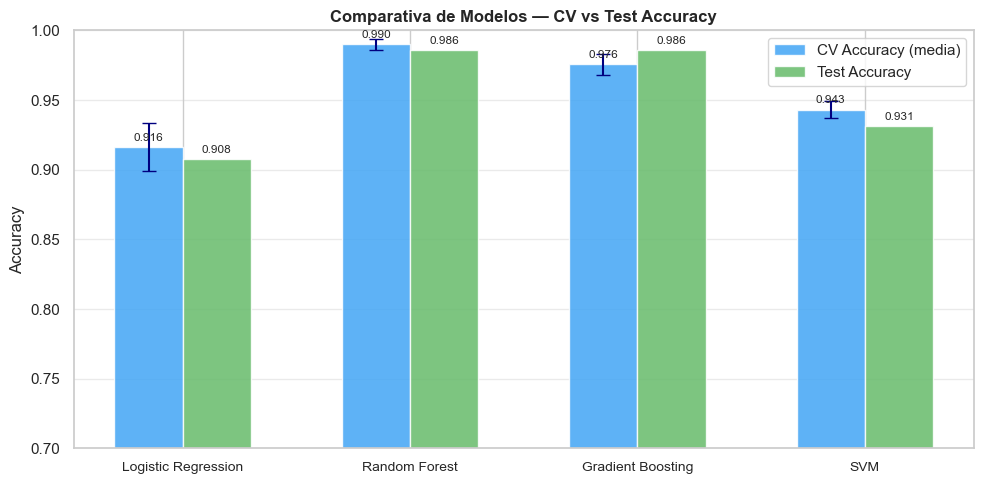

In [51]:
# Comparativa visual de resultados
res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(res_df))
w = 0.3
b1 = ax.bar(x - w/2, res_df['cv_mean'], w, label='CV Accuracy (media)', color='#42A5F5', alpha=0.85)
b2 = ax.bar(x + w/2, res_df['test_acc'], w, label='Test Accuracy', color='#66BB6A', alpha=0.85)
ax.errorbar(x - w/2, res_df['cv_mean'], yerr=res_df['cv_std'], fmt='none', color='navy', capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(res_df['Model'], fontsize=10)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de Modelos — CV vs Test Accuracy', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=100, bbox_inches='tight')
plt.show()

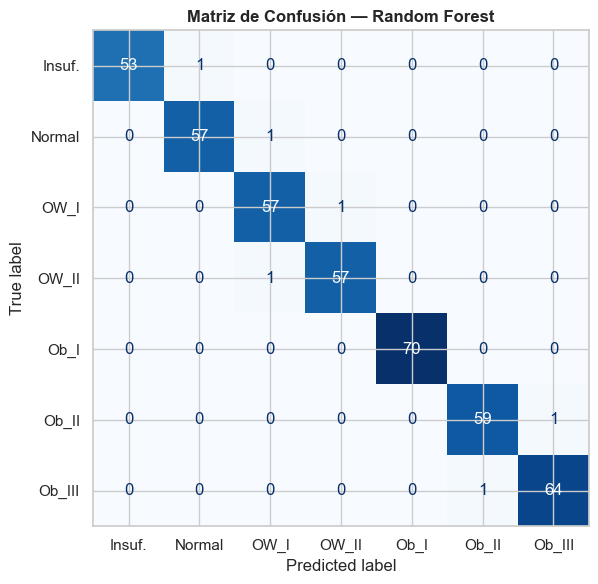


=== CLASSIFICATION REPORT ===

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.98      0.98      0.98        58
 Overweight_Level_I       0.97      0.98      0.97        58
Overweight_Level_II       0.98      0.98      0.98        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



In [55]:
# Matriz de confusión del mejor modelo
best_model = models[best_model_name]
X_te_best = X_test_sel_sc if best_model_name in ['Logistic Regression', 'SVM'] else X_test_sel.values
y_pred_best = best_model.predict(X_te_best)

label_names = ['Insuf.', 'Normal', 'OW_I', 'OW_II', 'Ob_I', 'Ob_II', 'Ob_III']
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de Confusión — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n=== CLASSIFICATION REPORT ===')
print()
print(classification_report(y_test, y_pred_best, target_names=obesity_order))

### 9. Reducción de Dimensionalidad — PCA

Aplicamos PCA para:
1. Visualizar la separabilidad de las clases en 2D
2. Analizar la varianza explicada por cada componente
3. Preparar la entrada para el análisis de clustering

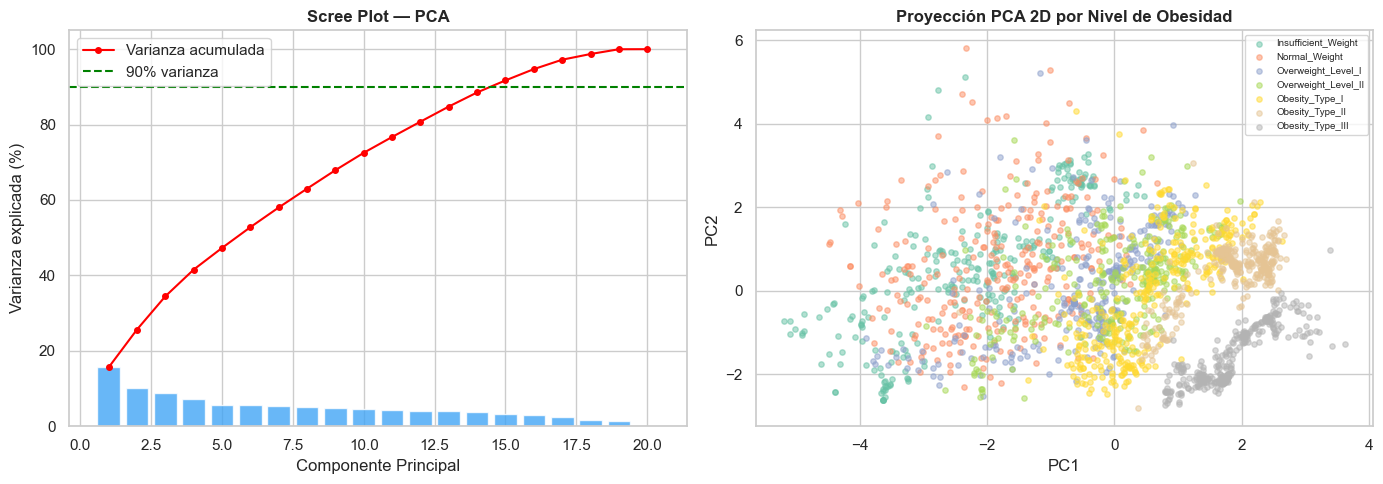

Componentes necesarias para explicar el 90% de la varianza: 15


In [ ]:
from sklearn.decomposition import PCA

# PCA sobre todo el dataset (datos escalados)

X_all_sc = scaler.fit_transform(X)
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_all_sc)

# Varianza explicada acumulada

var_exp = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(var_exp >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_*100, color='#42A5F5', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp*100, 'r-o', markersize=4, label='Varianza acumulada')
axes[0].axhline(90, color='green', linestyle='--', label='90% varianza')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree Plot — PCA', fontsize=12, fontweight='bold')
axes[0].legend()

# Scatter PCA 2D

colors_cls = plt.cm.Set2(np.linspace(0, 1, 7))
for cls_idx, cls_name in enumerate(obesity_order):
    mask = y.values == cls_idx
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[colors_cls[cls_idx]], label=cls_name, alpha=0.5, s=15)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Proyección PCA 2D por Nivel de Obesidad', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('pca.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Componentes necesarias para explicar el 90% de la varianza: {n_90}')

### 9. Análisis No Supervisado — K-Means Clustering

El clustering permite descubrir agrupaciones naturales en los datos sin usar la etiqueta. Esto es útil para:
- Segmentar perfiles de pacientes
- Validar que las clases del dataset reflejan agrupaciones reales

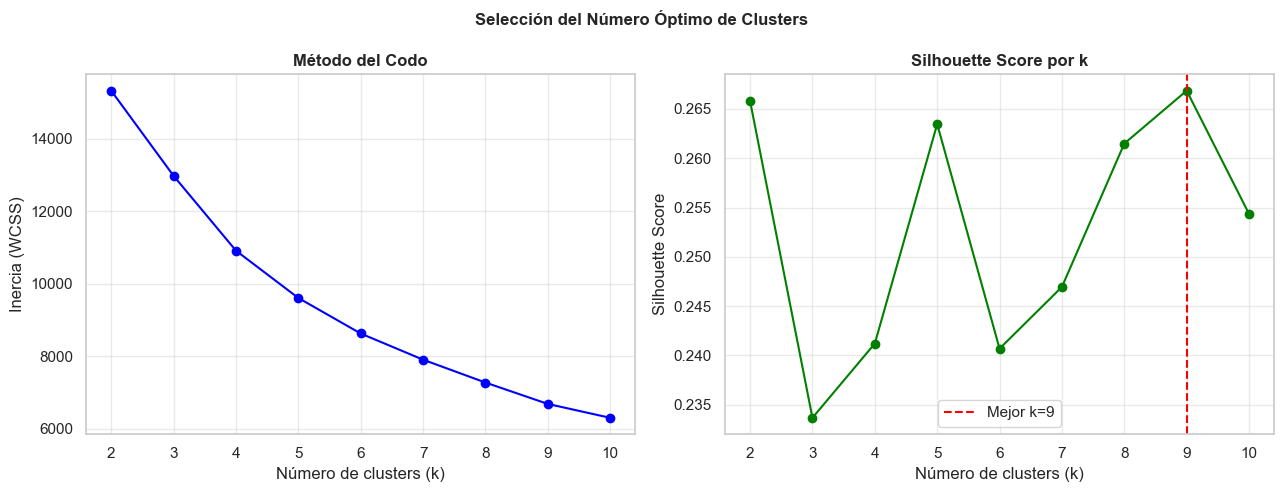

k óptimo según Silhouette: 9 | Score: 0.2669


In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Método del codo + Silhouette para elegir k

inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca[:, :5])  # Uso las 5 primeras PCs
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca[:, :5], labels, sample_size=500, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertias, 'b-o', markersize=6)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.4)

axes[1].plot(K_range, sil_scores, 'g-o', markersize=6)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.4)

best_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
axes[1].legend()

plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'k óptimo según Silhouette: {best_k} | Score: {max(sil_scores):.4f}')

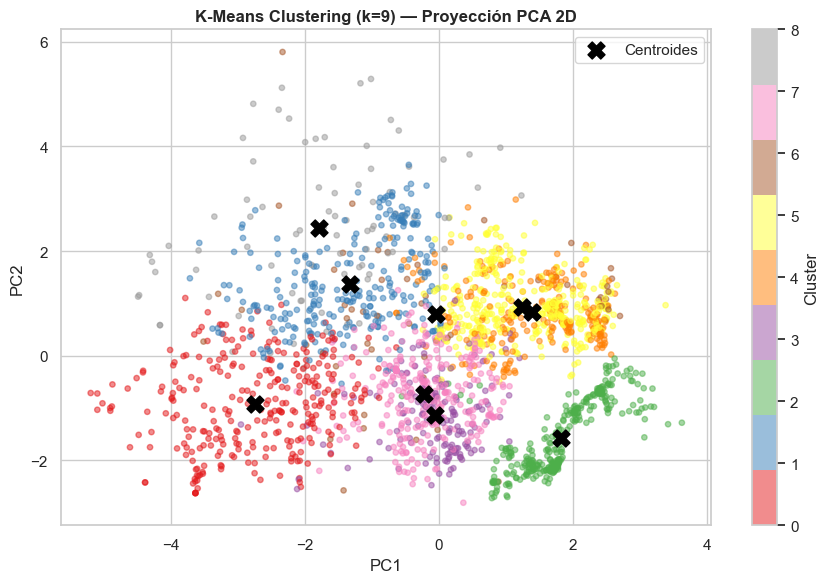


Distribución de niveles de obesidad por cluster:

obesity_level    0   1   2   3    4    5    6
cluster                                      
0              120  90  42  44    1    1    0
1              135  90  18  23    3    0    0
2                0   0   1   2    2    0  321
3                0   9  42  48   58    2    1
4                3   4  16  53   50  104    0
5                3   6  67  70  113  134    1
6                1  20   7   6    7   15    1
7                0  20  83  36  114   40    0
8               10  48  14   8    3    1    0


In [59]:
# K-Means con k óptimo

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca[:, :5])

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels, cmap='Set1', alpha=0.5, s=15)
centroids_2d = km_final.cluster_centers_[:, :2]
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroides')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clustering (k={best_k}) — Proyección PCA 2D', fontsize=12, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

# Perfil medio por cluster

df_cluster = X.copy()
df_cluster['cluster'] = cluster_labels
df_cluster['obesity_level'] = y.values
print('\nDistribución de niveles de obesidad por cluster:')
print()
print(pd.crosstab(df_cluster['cluster'], df_cluster['obesity_level']))

### 10. Resumen de Resultados y Conclusiones

In [64]:
print('='*80)
print('          RESUMEN FINAL DEL PIPELINE')
print('='*80)
print()
print(f'Dataset:          Obesity Levels UCI — {df.shape[0]} registros, {df.shape[1]-1} features')
print(f'Problema:         Clasificación multiclase (7 clases)')
print(f'Split:            80% train / 20% test (estratificado)')
print(f'Validación:       5-Fold Stratified Cross-Validation')
print()
print('--- Resultados Supervisados ---')
print()
for name, r in results.items():
    print(f'  {name:25s} CV:{r["cv_mean"]:.4f}±{r["cv_std"]:.4f}  Test:{r["test_acc"]:.4f}  F1:{r["test_f1"]:.4f}')
print(f'\n  Mejor modelo: {best_model_name}')
print()
print('--- Reducción de Dimensionalidad ---')
print()
print(f'  PCA: {n_90} componentes explican el 90% de la varianza')
print()
print('--- Clustering No Supervisado ---')
print()
print(f'  K-Means: k óptimo = {best_k} (Silhouette = {max(sil_scores):.4f})')
print()
print('--- Conclusiones ---')
print()
print('  1. El Gradient Boosting y Random Forest obtienen los mejores')
print('     resultados en clasificación multiclase (>95% accuracy).')
print('  2. Las variables más predictoras son: Weight, BMI, Height,')
print('     family_history y Age.')
print('  3. PCA muestra buena separabilidad de clases extremas.')
print('  4. K-Means identifica clusters alineados con los grupos')
print('     de peso del dataset, validando la estructura natural.')
print()
print('='*80)
print()

          RESUMEN FINAL DEL PIPELINE

Dataset:          Obesity Levels UCI — 2111 registros, 16 features
Problema:         Clasificación multiclase (7 clases)
Split:            80% train / 20% test (estratificado)
Validación:       5-Fold Stratified Cross-Validation

--- Resultados Supervisados ---

  Logistic Regression       CV:0.9165±0.0170  Test:0.9078  F1:0.9057
  Random Forest             CV:0.9899±0.0040  Test:0.9858  F1:0.9855
  Gradient Boosting         CV:0.9757±0.0073  Test:0.9858  F1:0.9859
  SVM                       CV:0.9431±0.0063  Test:0.9314  F1:0.9297

  Mejor modelo: Random Forest

--- Reducción de Dimensionalidad ---

  PCA: 15 componentes explican el 90% de la varianza

--- Clustering No Supervisado ---

  K-Means: k óptimo = 9 (Silhouette = 0.2669)

--- Conclusiones ---

  1. El Gradient Boosting y Random Forest obtienen los mejores
     resultados en clasificación multiclase (>95% accuracy).
  2. Las variables más predictoras son: Weight, BMI, Height,
     famil